In [1]:
import pandas as pd

df = pd.read_csv("risk_factors_cervical_cancer.csv")

In [3]:
df.head()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
2,34,1.0,?,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,?,?,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,?,?,0,0,0,0,0,0,0,0


In [5]:
df.shape

(858, 36)

In [7]:
df = df.replace('?', pd.NA)

In [9]:
df = df.apply(pd.to_numeric)

In [11]:
df = df.fillna(df.mean())

In [13]:
df['Biopsy']

0      0
1      0
2      0
3      0
4      0
      ..
853    0
854    0
855    0
856    0
857    0
Name: Biopsy, Length: 858, dtype: int64

In [15]:
df['Biopsy'].value_counts()

Biopsy
0    803
1     55
Name: count, dtype: int64

In [17]:
X = df.drop(['Biopsy'], axis=1)
y = df['Biopsy']

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [25]:
y_pred = model.predict(X_test)

In [27]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9418604651162791


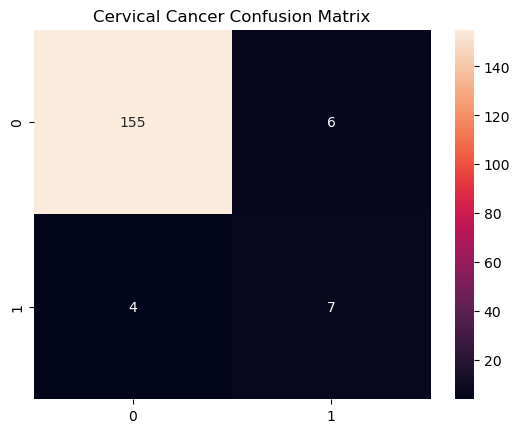

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Cervical Cancer Confusion Matrix")
plt.show()

In [31]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [33]:
rf_pred = rf_model.predict(X_test)

In [35]:
rf_accuracy = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9302325581395349


In [37]:
import pickle

pickle.dump(rf_model, open("cervical_cancer_model.pkl", "wb"))

In [39]:
from sklearn.ensemble import RandomForestClassifier

In [41]:
rf_model = RandomForestClassifier(random_state=42)

In [43]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [45]:
rf_pred = rf_model.predict(X_test)

In [47]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9302325581395349


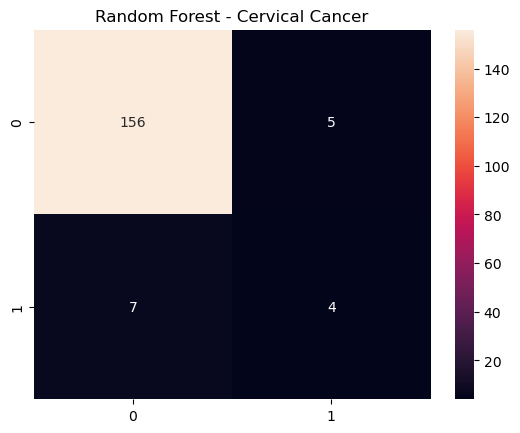

In [49]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Random Forest - Cervical Cancer")
plt.show()

In [51]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.96      0.97      0.96       161
           1       0.44      0.36      0.40        11

    accuracy                           0.93       172
   macro avg       0.70      0.67      0.68       172
weighted avg       0.92      0.93      0.93       172



In [53]:
import pandas as pd

importance = pd.Series(rf_model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10)

Schiller                           0.295592
Hinselmann                         0.096288
Age                                0.093572
First sexual intercourse           0.075097
Citology                           0.061981
Hormonal Contraceptives (years)    0.061709
Num of pregnancies                 0.049562
Number of sexual partners          0.048629
Smokes (years)                     0.018783
Hormonal Contraceptives            0.018182
dtype: float64

In [55]:
import pickle

pickle.dump(rf_model, open("cervical_rf_model.pkl", "wb"))